In [48]:
import accelforge as af
from scheduling.scheduler import *
from af_wrapper import *
import numpy as np


def run(
    einsums,
    compute_units,
    data_dependencies,
    latency_per_component_grid = None,
    total_latency_grid = None,
    actions_grid = None,
    memory_name = None,
    shared_memory_info = None,
):
    schedule, min_latency = best_schedule(
        einsums,
        compute_units,
        shared_memory_info,
        data_dependencies,
        latency_per_component_grid,
        total_latency_grid,
        actions_grid,
        memory_name
    )
    return schedule, min_latency


In [49]:
arch = "arch/old-eyeriss-split-mem/full.yaml"
workload = "workload/bw-sharing-case-study/mm.yaml"
data_dependencies = {
    "Matmul1": [],
    "Matmul2": []
}
compute_units = ['fast', 'slow']
einsums = data_dependencies.keys()
memory_name = "MainMemory"

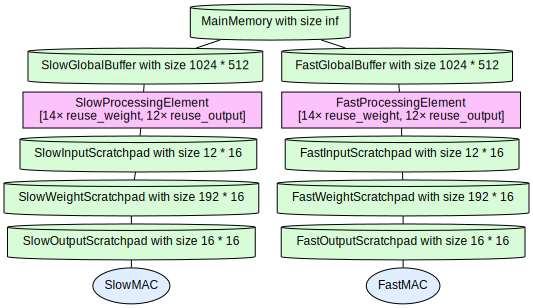

In [50]:
af.Spec.from_yaml(arch, workload).arch

In [51]:
%%capture af_output 
af_baseline = af_map(arch, workload)

Generating pmapping templates for compute SlowMAC Einsum Matmul2: 16it [00:00, 84.41it/s]
Generating pmapping templates for compute SlowMAC Einsum Matmul1: 16it [00:00, 55.29it/s]
Generating pmapping templates for compute FastMAC Einsum Matmul2: 16it [00:00, 87.10it/s]
Generating pmapping templates for compute FastMAC Einsum Matmul1: 16it [00:00, 86.41it/s]


In [52]:
with open("images/af_baseline-big-2rectmm-eyeriss_dual_identical.svg", "w") as f:
    f.write(af_baseline.render())

In [53]:
af_baseline.latency(per_einsum=True, per_component=True)

{('Matmul1', 'FastMAC'): 0.010485759936273098,
 ('Matmul1', 'FastInputScratchpad'): 0.01178429089486599,
 ('Matmul1', 'FastGlobalBuffer'): 0.004648960195481777,
 ('Matmul1', 'MainMemory'): 0.011801600456237793,
 ('Matmul1', 'FastWeightScratchpad'): 0.0034257054794579744,
 ('Matmul1', 'FastOutputScratchpad'): 0.012517932802438736,
 ('Matmul2', 'FastMAC'): 0.010485759936273098,
 ('Matmul2', 'FastInputScratchpad'): 0.01178429089486599,
 ('Matmul2', 'FastGlobalBuffer'): 0.004628320224583149,
 ('Matmul2', 'MainMemory'): 0.010480640456080437,
 ('Matmul2', 'FastWeightScratchpad'): 0.0034257054794579744,
 ('Matmul2', 'FastOutputScratchpad'): 0.012517932802438736}

In [54]:
mems = sum(n for ((unit, act), n) in af_baseline[0].actions(per_component=True).items() if unit == 'MainMemory')
mems

np.float64(142606336.0)

In [55]:
af_baseline.latency()

0.025035865604877472

In [56]:
(mems/af_baseline.latency()) / 6.4e9

np.float64(0.8900127661517319)

In [57]:
%%capture grid_out
# this is for bw-aware version
# RUN TO GENERATE ACCELFORGE VALUES.
# To skip recomputation when running with fresh kernel, comment out
# this cell and use the below assignments instead.

arch = "arch/old-eyeriss-split-mem/full.yaml"
workload = "workload/bw-sharing-case-study/mm.yaml"

(grid_lats, grid_mems, grid_maps) = af_memoizable_grid(
    einsums, 
    compute_units,
    lambda einsum: "workload/bw-sharing-case-study/"+einsum+".yaml",
    lambda sub_arch: "arch/old-eyeriss-split-mem/"+sub_arch+".yaml",
    # just_one = True
)

In [58]:
grid_lats

{('fast', 'Matmul1'): {'FastMAC': np.float32(0.01048576),
  'FastInputScratchpad': np.float32(0.0060762754),
  'FastGlobalBuffer': np.float32(0.00083968),
  'MainMemory': np.float32(0.0118016),
  'FastWeightScratchpad': np.float32(0.0034257055),
  'FastOutputScratchpad': np.float32(0.012517933)},
 ('fast', 'Matmul2'): {'FastMAC': np.float32(0.01048576),
  'FastInputScratchpad': np.float32(0.011784291),
  'FastGlobalBuffer': np.float64(0.00454656),
  'MainMemory': np.float32(0.01048064),
  'FastWeightScratchpad': np.float32(0.0034257055),
  'FastOutputScratchpad': np.float32(0.012517933)},
 ('slow', 'Matmul1'): {'SlowMAC': np.float32(0.01048576),
  'SlowInputScratchpad': np.float32(0.0060762754),
  'SlowGlobalBuffer': np.float32(0.00084976),
  'MainMemory': np.float32(0.01244672),
  'SlowWeightScratchpad': np.float32(0.0034257055),
  'SlowOutputScratchpad': np.float32(0.012517933)},
 ('slow', 'Matmul2'): {'SlowMAC': np.float32(0.01048576),
  'SlowInputScratchpad': np.float32(0.011784291

In [68]:
onem = list(grid_maps.values())[0]

(sum(n for ((unit, act), n) in onem.actions(per_component=True).items() if unit == 'MainMemory')/onem.latency()) / 6.4e9

np.float64(0.9427754714980431)

In [42]:
onem.latency()

np.float32(0.012517933)

In [59]:
# The schedule with ONLY 50/50 split of shared memory, with bandwidth utilization considering

schedule, latency = run(
    einsums,
    compute_units,
    data_dependencies,
    latency_per_component_grid = grid_lats,
    actions_grid = grid_mems,
    memory_name = memory_name
)

Assignment 0 of 4
0
Executing: []
available: 1
Start time of (Matmul2, fast, latency=0.012517932802438736) : 0
Chunks:
[{'einsum': 'Matmul2', 'start': 0, 'end': np.float32(0.012517933), 'bwu': np.float32(0.8372501)}]

0.012517933
Executing: []
available: 1
Start time of (Matmul1, fast, latency=0.012517932802438736) : 0.012517933
Chunks:
[{'einsum': 'Matmul2', 'start': 0, 'end': np.float32(0.012517933), 'bwu': np.float32(0.8372501)}, {'einsum': 'Matmul1', 'start': np.float32(0.012517933), 'end': np.float32(0.025035866), 'bwu': np.float32(0.9427755)}]

0
Executing: []
available: 1
Start time of (Matmul1, fast, latency=0.012517932802438736) : 0
Chunks:
[{'einsum': 'Matmul1', 'start': 0, 'end': np.float32(0.012517933), 'bwu': np.float32(0.9427755)}]

0.012517933
Executing: []
available: 1
Start time of (Matmul2, fast, latency=0.012517932802438736) : 0.012517933
Chunks:
[{'einsum': 'Matmul1', 'start': 0, 'end': np.float32(0.012517933), 'bwu': np.float32(0.9427755)}, {'einsum': 'Matmul2', 's

In [60]:
schedule

{(Matmul1, fast, latency=0.012517932802438736): 0,
 (Matmul2, slow, latency=0.024180287814075108): 0}

In [61]:
latency

np.float64(0.024180287814075108)

In [62]:
# for node in schedule.keys():
#     for (action, count) in grid_mems[(node.compute_assignment, node.einsum_name)].items():
#         if action[0] == memory_name:
#             print(node, action, count)

            
mems = sum(
    sum(
        count
        for (action, count) in grid_mems[(node.compute_assignment, node.einsum_name)].items()
        if action[0] == memory_name
    ) 
    for node in schedule.keys()
)
mems

np.float64(142606336.0)

In [63]:
# bwu
(mems/latency) / 6.4e9 # old schedule: np.float64(0.4762258443913986)

np.float64(0.921504333254037)